11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9182 - loss: 0.2672 - val_accuracy: 0.9852 - val_loss: 0.0535
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9720 - loss: 0.0952 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 78s 53ms/step - accuracy: 0.9785 - loss: 0.0703 - val_accuracy: 0.9903 - val_loss: 0.0355
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 56ms/step - accuracy: 0.9821 - loss: 0.0579 - val_accuracy: 0.9910 - val_loss: 0.0336
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 53ms/step - accuracy: 0.9863 - loss: 0.0462 - val_accuracy: 0.9915 - val_loss: 0.0307
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9919 - loss: 0.0244
Test Accuracy: 0.9919000267982483


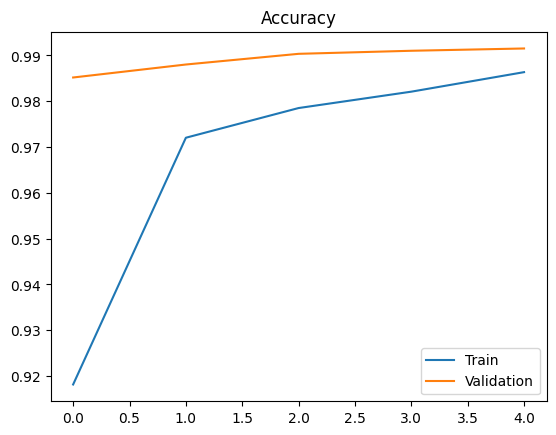

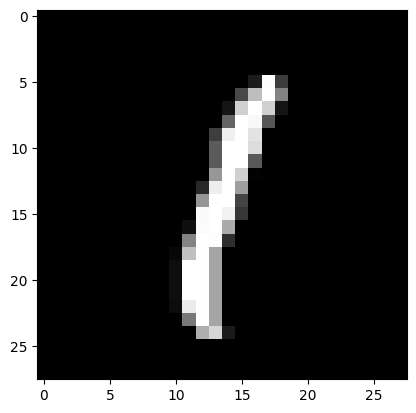

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted: 1


In [ ]:
# Import libraries
import numpy as np              # Numerical operations
import matplotlib.pyplot as plt # Plot graphs
import tensorflow as tf         # Deep learning framework

from tensorflow.keras.datasets import mnist            # Load MNIST data
from tensorflow.keras.models import Sequential         # Model type
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # Layers
from tensorflow.keras.utils import to_categorical      # One-hot encoding


# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()  # Load data


# Preprocessing
X_train = X_train.reshape(-1, 28, 28, 1)   # Add channel dimension
X_test = X_test.reshape(-1, 28, 28, 1)     # Add channel dimension

X_train = X_train / 255.0  # Normalize pixels
X_test = X_test / 255.0    # Normalize pixels

y_train = to_categorical(y_train, 10)  # Convert labels to one-hot
y_test = to_categorical(y_test, 10)    # Convert labels to one-hot


# Build CNN model
model = Sequential()  # Initialize model

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))  # Conv layer
model.add(MaxPooling2D(2,2))  # Pooling layer

model.add(Conv2D(64, (3,3), activation='relu'))  # Conv layer
model.add(MaxPooling2D(2,2))  # Pooling layer

model.add(Flatten())  # Convert to 1D

model.add(Dense(128, activation='relu'))  # Fully connected layer
model.add(Dropout(0.5))  # Reduce overfitting

model.add(Dense(10, activation='softmax'))  # Output layer


# Compile model
model.compile(optimizer='adam',              # Optimizer
              loss='categorical_crossentropy',  # Loss function
              metrics=['accuracy'])             # Evaluation metric


# Train model
history = model.fit(X_train, y_train,   # Training data
                    epochs=5,           # Number of iterations
                    batch_size=64,      # Batch size
                    validation_split=0.1)  # Validation data


# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)  # Test performance
print("Test Accuracy:", test_acc)  # Print accuracy


# Plot accuracy
plt.plot(history.history['accuracy'])      # Train accuracy
plt.plot(history.history['val_accuracy'])  # Validation accuracy
plt.legend(['Train', 'Validation'])        # Legend
plt.title("Accuracy")                      # Title
plt.show()                                # Show plot


# Prediction
import random  # Random selection

index = random.randint(0, len(X_test)-1)  # Pick random image
sample = X_test[index]                   # Get image

plt.imshow(sample.reshape(28,28), cmap='gray')  # Show image
plt.show()  # Display image

prediction = model.predict(sample.reshape(1,28,28,1))  # Predict
print("Predicted:", np.argmax(prediction))  # Show result